In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import hoda
import tensorly as tl
import os

%env TENSORLY_BACKEND=numpy
%env CUPY_CUDA_PER_THREAD_DEFAULT_STREAM=1


tl.set_backend(os.environ['TENSORLY_BACKEND'])
tl.get_backend()

env: TENSORLY_BACKEND=numpy
env: CUPY_CUDA_PER_THREAD_DEFAULT_STREAM=1


'numpy'

In [3]:
from moabb.paradigms import P300
from moabb.datasets import *


paradigm = P300(resample=48)
dataset = BNCI2015003()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[2],
     return_epochs=True
)
session = meta['session'][1]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]



BNCI2015003 has been renamed to BNCI2015_003. BNCI2015003 will be removed in version 1.1.
The dataset class name 'BNCI2015003' must be an abbreviation of its code 'BNCI2015-003'. See moabb.datasets.base.is_abbrev for more information.
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  2700 events (all good), 0 – 0.800781 s, baseline off, ~34.0 MB, data loaded,
 'Target': 75
 'NonTarget': 2625>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  2700 events (all good), 0 – 0.800781 s, baseline off, ~34.0 MB, data loaded,
 'Target': 75
 'NonTarget': 2625>
  warn(f"warnEpochs {epochs}")


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
5400 matching events found
No baseline correction applied


/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/paradigms/base.py:350: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = tl.tensor(epochs.get_data())
y = labels

/tmp/ipykernel_1794196/3223033590.py:5: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = tl.tensor(epochs.get_data())


In [5]:
#%env PYTHONWARNINGS=error

In [6]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFwe
from hoda.classification import SelectF

clf = make_pipeline(
    SelectF(),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

bttda = GreedyBTTDA(
    max_blocks=4,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,#(1,),
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
    ),
    #rank_grid=[1],
    verbose=True,
    extra_train_info=False,
    n_jobs=1,
    cv= StratifiedKFold(random_state=42,shuffle=True),
    truncate=True,
    clf=clf,
)
bttda.fit(X,y, test=True)

Model selection block 1/4...

Trying rank (1, 1)	score: 0.9325
Trying rank (2, 2)	score: 0.9315
Trying rank (4, 4)	score: 0.9271
Trying rank (8, 8)	score: 0.8498
Trying rank (8, 16)	score: 0.8347
Trying rank (8, 32)	score: 0.9034

Selected rank (1, 1) with score 0.9325
New ranks: [(1, 1)]


Model selection block 2/4...

Trying rank (1, 1)	score: 0.9438
Trying rank (2, 2)	score: 0.9428
Trying rank (4, 4)	score: 0.9425
Trying rank (8, 8)	score: 0.9336
Trying rank (8, 16)	score: 0.9265
Trying rank (8, 32)	score: 0.9270

Selected rank (1, 1) with score 0.9438
New ranks: [(1, 1), (1, 1)]


Model selection block 3/4...

Trying rank (1, 1)	score: 0.9339
Trying rank (2, 2)	score: 0.9441
Trying rank (4, 4)	score: 0.9438
Trying rank (8, 8)	score: 0.9388
Trying rank (8, 16)	score: 0.9354
Trying rank (8, 32)	score: 0.9314

Selected rank (2, 2) with score 0.9441
New ranks: [(1, 1), (1, 1), (2, 2)]


Model selection block 4/4...

Trying rank (1, 1)	score: 0.9361
Trying rank (2, 2)	score: 0.9380
Tryi

GreedyBTTDA(clf=Pipeline(steps=[('selectf', SelectF()),
                                ('functiontransformer',
                                 FunctionTransformer(func=<function NumpyBackend.to_numpy at 0x14c4781399e0>)),
                                ('standardscaler', StandardScaler()),
                                ('lineardiscriminantanalysis',
                                 LinearDiscriminantAnalysis(shrinkage='auto',
                                                            solver='lsqr'))]),
            cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
            hoda_params={'delta': None, 'extra_train_info': False,
                         'init': 'random', 'max_iter': 128, 'obj': 'tr',
                         'random_state': 42, 'rank': (2, 2), 'shrinkage': 'lw',
                         'solver': 'lanczos', 'taper': False, 'toeplitz': None,
                         'tol': 1e-08, 'verbose': False},
            max_blocks=4, n_jobs=1, verbose=True)

In [7]:
bttda.model_select_info_

fold  train_score  val_score  n_features  test_score
block rank                                                         
0     (1, 1)      0     0.953997   0.951300           1    0.925149
      (1, 1)      1     0.963515   0.899033           1    0.924671
      (1, 1)      2     0.952241   0.960709           1    0.926021
      (1, 1)      3     0.958649   0.921936           1    0.920566
      (1, 1)      4     0.960939   0.929762           1    0.927314
...             ...          ...        ...         ...         ...
3     (8, 32)     0     0.985797   0.953937         262    0.884912
      (8, 32)     1     0.986811   0.914905         262    0.863008
      (8, 32)     2     0.986792   0.933826         262    0.861180
      (8, 32)     3     0.986827   0.918420         262    0.866297
      (8, 32)     4     0.987195   0.939534         262    0.887583

[120 rows x 5 columns]

In [8]:
bttda.model_select_info_best_

fold  train_score  val_score  n_features  test_score
block rank                                                        
0     (1, 1)     0     0.953997   0.951300           1    0.925149
      (1, 1)     1     0.963515   0.899033           1    0.924671
      (1, 1)     2     0.952241   0.960709           1    0.926021
      (1, 1)     3     0.958649   0.921936           1    0.920566
      (1, 1)     4     0.960939   0.929762           1    0.927314
1     (1, 1)     0     0.972986   0.954506           2    0.901417
      (1, 1)     1     0.973008   0.943184           2    0.905888
      (1, 1)     2     0.969526   0.957039           2    0.896075
      (1, 1)     3     0.973683   0.919868           2    0.896609
      (1, 1)     4     0.975902   0.944494           2    0.901333
2     (2, 2)     0     0.977954   0.954867           6    0.888033
      (2, 2)     1     0.981152   0.946441           6    0.900489
      (2, 2)     2     0.977353   0.941891           6    0.892616
      (2, 2)     3     0.975988   0.923176           6    0.891969
      (2, 2)     4     0.981663   0.954167           6    0.895203
3     (4, 4)     0     0.979607   0.940392          22    0.873552
      (4, 4)     1     0.982987   0.937600          22    0.888792
      (4, 4)     2     0.979841   0.938686          22    0.884827
      (4, 4)     3     0.979575   0.939565          22    0.887442
      (4, 4)     4     0.984100   0.939782          22    0.889579

In [9]:
bttda.model_select_info_best_.groupby(['block', 'rank'])['val_score'].aggregate('mean')

block  rank  
0      (1, 1)    0.932548
1      (1, 1)    0.943818
2      (2, 2)    0.944108
3      (4, 4)    0.939205
Name: val_score, dtype: float64

In [10]:
bttda.model_select_info_best_.groupby(['block', 'rank'])['test_score'].aggregate('mean')

block  rank  
0      (1, 1)    0.924744
1      (1, 1)    0.900264
2      (2, 2)    0.893662
3      (4, 4)    0.884839
Name: test_score, dtype: float64

block  rank  
0      (1, 1)    0.807051
1      (8, 8)    0.820216
2      (8, 8)    0.825298
3      (8, 8)    0.828784
4      (4, 4)    0.829647
5      (8, 8)    0.832404
6      (8, 8)    0.834165
7      (4, 4)    0.835178
Name: val_score, dtype: float64

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:111

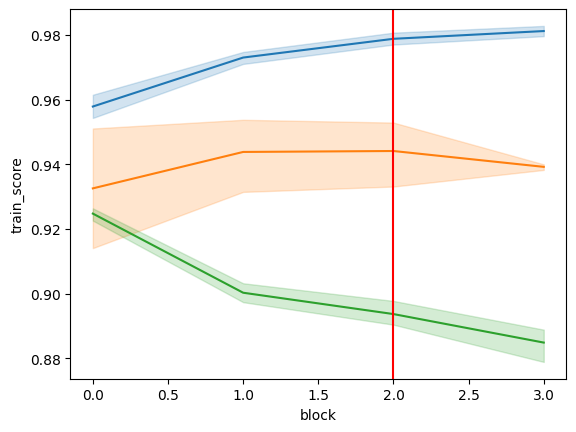

In [11]:
import seaborn as sns 
import matplotlib.pyplot as plt

plt.style.use('default')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='train_score')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='val_score')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='test_score')
plt.axvline(bttda.n_blocks_-1, color='red')

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='block', ylabel='n_features'>

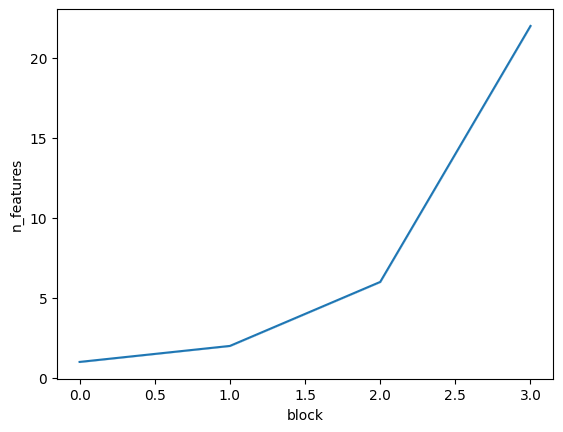

In [12]:
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='n_features')


/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:111

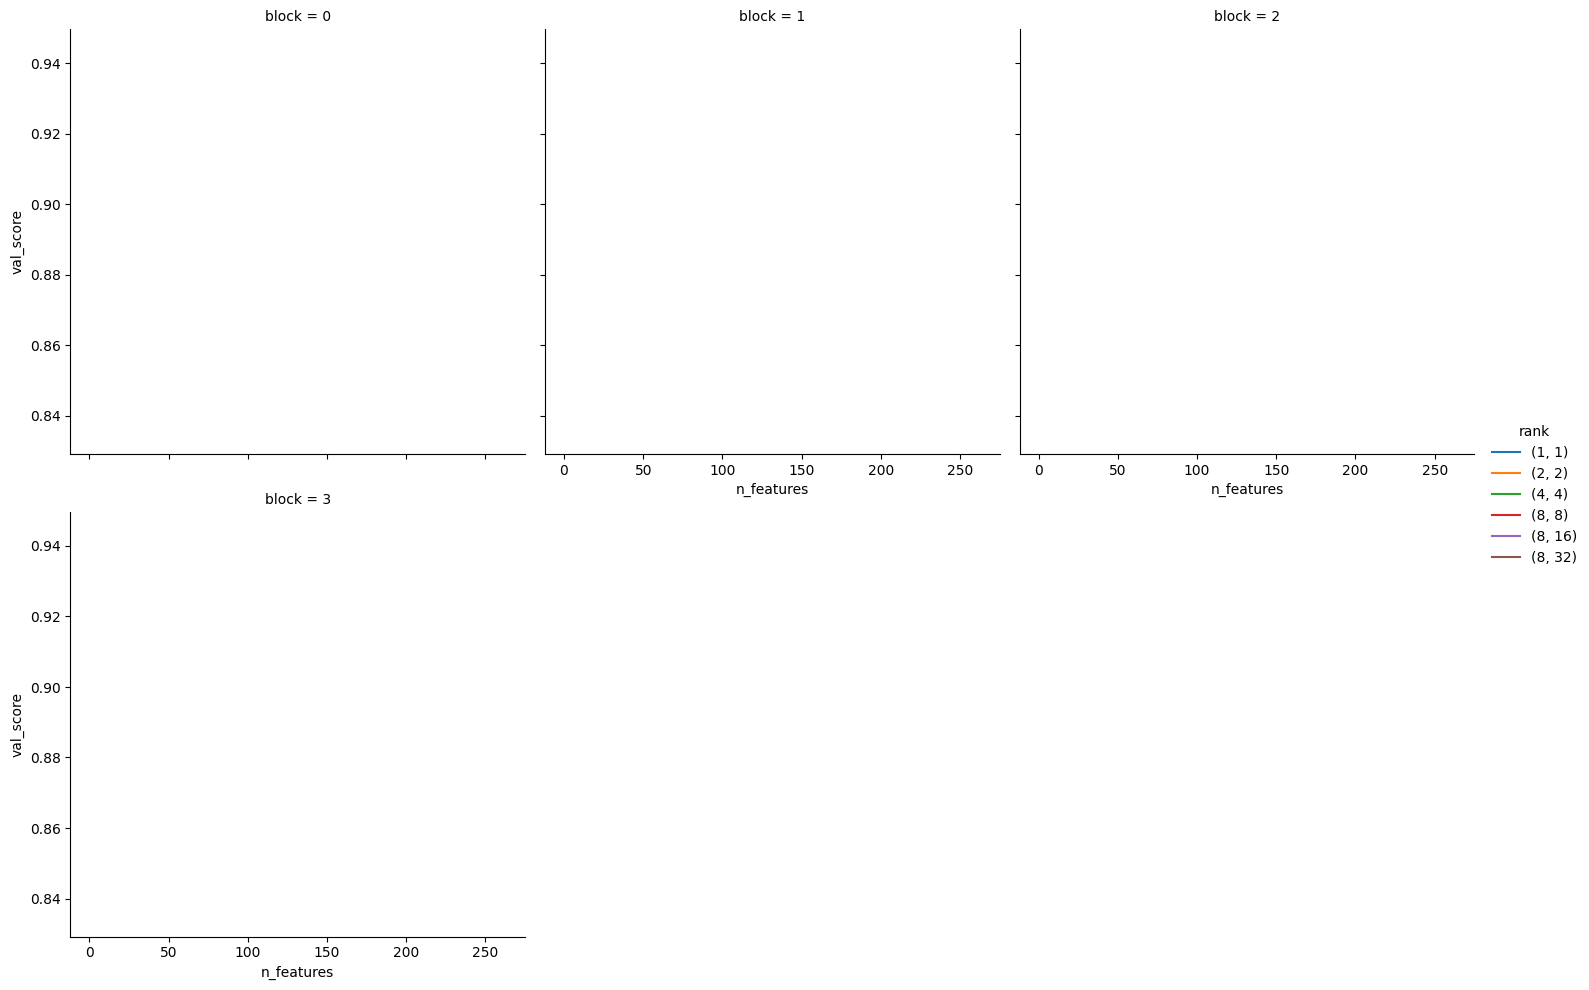

In [13]:
sns.relplot(
    data=bttda.model_select_info_.reset_index(),
    x='n_features',
    y='val_score',
    hue='rank',
    palette='tab10',
    col='block',
    kind='line',
    col_wrap=3,
    errorbar=None,
)
#plt.xscale('log')